# Import

In [67]:
import logging, warnings; logging.getLogger().setLevel(logging.ERROR);
warnings.filterwarnings("ignore")

import scanpy as sc
import scanpy.external as sce
import numpy as np
import pandas as pd
import re
from pathlib import Path 
import scipy.io
import scipy.sparse as sp

import warnings, scipy.sparse as sp, matplotlib, matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.pyplot import rc_context
import matplotlib.font_manager
import matplotlib.lines as lines


pd.set_option('display.max_rows', 200)

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = 'Arial'
matplotlib.rc('font', size=12)

sc.settings.n_jobs=-1
sc.set_figure_params(dpi=80, dpi_save=300, color_map='Spectral_r', vector_friendly=True, transparent=True)
sc.settings.figdir = '../1_outputs/0_figures'
sc.settings.verbosity = 1 # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()

%matplotlib inline 
%config InlineBackend.figure_format = 'retina'

In [68]:
def observe_variance(anndata_object):
    fig = plt.figure(figsize=(10,5))
    ax1 = fig.add_subplot(121)
    ax2 = fig.add_subplot(122)
    # variance per principal component
    x = range(len(anndata_object.uns['pca']['variance_ratio']))
    y = anndata_object.uns['pca']['variance_ratio']
    ax1.scatter(x,y,s=4)
    ax1.set_xlabel('PC')
    ax1.set_ylabel('Fraction of variance explained\n')
    ax1.set_title('Fraction of variance explained per PC\n')
    # cumulative variance explained
    cml_var_explained = np.cumsum(anndata_object.uns['pca']['variance_ratio'])
    x = range(len(anndata_object.uns['pca']['variance_ratio']))
    y = cml_var_explained
    ax2.scatter(x,y,s=4)
    ax2.set_xlabel('PC')
    ax2.set_ylabel('Cumulative fraction of variance\nexplained')
    ax2.set_title('Cumulative fraction of variance\nexplained by PCs')
    fig.tight_layout()
    plot = plt.show
    return(plot)

In [69]:
def sanitize_sheet_name(name):
    return name.replace(':', '_')

In [70]:
pwd

'/coh_labs/mvandenbrink/users/pkaur/6_tff1/1_treg_sltbi/0_pyzone/0_scRNA/0_notebooks'

In [71]:
file_outputs = '../1_outputs/' 
h5ad = '../1_outputs/1_h5ad/'
degs = '../1_outputs/2_degs/'

In [72]:
thymus = sc.read_h5ad(h5ad + '5_thymus.h5ad' )
spleen = sc.read_h5ad(h5ad + '6_spleen.h5ad' )
bm = sc.read_h5ad(h5ad + '7_bm.h5ad' )
liver = sc.read_h5ad(h5ad + '8_liver.h5ad' )
lung = sc.read_h5ad(h5ad + '9_lung.h5ad')
skin = sc.read_h5ad(h5ad + '10_skin.h5ad')
adata = sc.read_h5ad(h5ad + '11_adata_final.h5ad')

In [73]:
adata

AnnData object with n_obs × n_vars = 30553 × 20682
    obs: 'tissue', 'hash_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'original_total_counts', 'log10_original_total_counts', 'mito_frac', 'ribo_frac', 'hb_frac', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet', 'n_counts', 'leiden_0.1', 'leiden_0.2', 'leiden_0.3', 'leiden_0.4', 'leiden_0.5', 'leiden_0.6', 'leiden_0.7', 'leiden_0.8', 'leiden_0.9', 'leiden_1.0', 'keep_cell', 'tissue_labeled', 'spectra50', 'treg_regen', 'treg_supress', 'treg_naive', 'treg_status'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'neighbors', 'pca', 'tissue_labeled_colors', 'treg_status_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'raw_data'
    obsp: 'connectivities', 'distances'

# DEGs Regen vs Quiescent

In [23]:
writer = pd.ExcelWriter(degs + 'tissues_regen_quiescent.xlsx', engine='xlsxwriter')

In [24]:
tissue_types_list = adata.obs['tissue_labeled'].unique().tolist()
tissue_types_list

['0:Thymus', '1:Spleen', '2:BM', '3:Liver', '4:Lung', '5:Skin']

In [ ]:
for tissue_type in tissue_types_list:
    adata_tissue = adata[adata.obs['tissue_labeled'].isin([tissue_type])].copy()

    statuses = adata_tissue.obs['treg_status'].unique().tolist()
    if '0:Regenerative' not in statuses or '1:Quiescent' not in statuses:
        print(f'Skipping {tissue_type}: missing Regenerative or Quiescent cells (found: {statuses})')
        continue

    sc.tl.rank_genes_groups(
        adata_tissue,
        'treg_status',
        groups=['0:Regenerative'],
        reference='1:Quiescent',
        method='wilcoxon',
        use_raw=False
    )
    result = adata_tissue.uns['rank_genes_groups']
    groups = result['names'].dtype.names
    df = pd.DataFrame(
        {group + '_' + key[:1]: result[key][group]
         for group in groups for key in ['names', 'scores', 'logfoldchanges', 'pvals_adj']}
    )

    logfoldchange_cols = [col for col in df.columns if col.endswith('_l')]
    pval_cols = [col for col in df.columns if col.endswith('_p')]

    if logfoldchange_cols and pval_cols:
        df['Is Significant'] = (df[logfoldchange_cols[0]].abs() >= 0.5) & (df[pval_cols[0]] <= 0.05)

    df.to_excel(writer, sheet_name=sanitize_sheet_name(tissue_type))

writer.close()

# Volcano Plots — Regen vs Quiescent

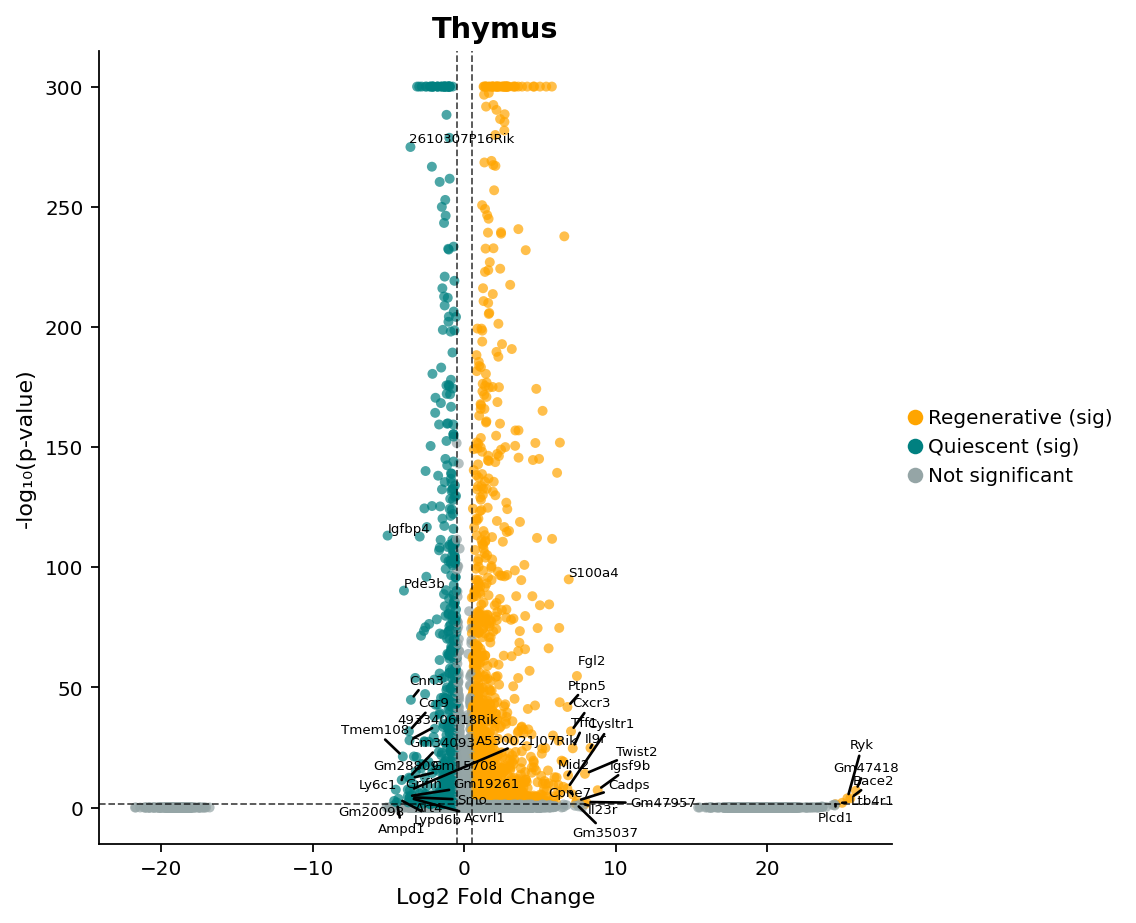

In [81]:
# ── Thymus ─────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

xlsx_path = degs + 'tissues_regen_quiescent.xlsx'
LFC_CUTOFF = 0.5
PVAL_CUTOFF = 0.05
N_LABELS = 20
DOT_SIZE = 20  # increase to make dots bigger
LABEL_GENES = []  # e.g. ['FOXP3', 'IL2RA'] — overrides auto top-N when non-empty

sheet = '0_Thymus'
try:
    df = pd.read_excel(xlsx_path, sheet_name=sheet)
except Exception:
    print(f'Sheet {sheet} not found — tissue may have been skipped during DEG analysis.')
    raise

lfc_col  = [c for c in df.columns if c.endswith('_l')][0]
pval_col = [c for c in df.columns if c.endswith('_p')][0]
name_col = [c for c in df.columns if c.endswith('_n')][0]

df = df.dropna(subset=[lfc_col, pval_col])
df['neglog10p'] = -np.log10(df[pval_col].clip(lower=1e-300))
df['sig'] = (df[lfc_col].abs() >= LFC_CUTOFF) & (df[pval_col] < PVAL_CUTOFF)

def _color(row):
    if row['sig'] and row[lfc_col] >= LFC_CUTOFF:
        return 'Orange'    # upregulated in Regenerative
    elif row['sig'] and row[lfc_col] <= -LFC_CUTOFF:
        return 'Teal'      # upregulated in Quiescent
    return '#95A5A6'       # not significant

colors = df.apply(_color, axis=1)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(df[lfc_col], df['neglog10p'], c=colors, s=DOT_SIZE, alpha=0.7, linewidths=0, rasterized=True)

ax.axvline(x= LFC_CUTOFF, color='black', linestyle='--', linewidth=0.8, alpha=0.7)
ax.axvline(x=-LFC_CUTOFF, color='black', linestyle='--', linewidth=0.8, alpha=0.7)
ax.axhline(y=-np.log10(PVAL_CUTOFF), color='black', linestyle='--', linewidth=0.8, alpha=0.7)

if LABEL_GENES:
    label_df = df[df[name_col].isin(LABEL_GENES)]
else:
    sig_df = df[df['sig']].copy()
    label_df = pd.concat([
        sig_df.nlargest(N_LABELS, lfc_col),
        sig_df.nsmallest(N_LABELS, lfc_col)
    ]).drop_duplicates()
from adjustText import adjust_text
texts = []
for _, row in label_df.iterrows():
    texts.append(ax.text(row[lfc_col], row['neglog10p'], row[name_col],
                         fontsize=6, color='black'))
adjust_text(texts, ax=ax,
            arrowprops=dict(arrowstyle='-', color='black', lw=1.2))

ax.set_title('Thymus', fontsize=13, fontweight='bold')
ax.set_xlabel('Log2 Fold Change', fontsize=10)
ax.set_ylabel('-log₁₀(p-value)', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.set_box_aspect(1)
ax.tick_params(labelsize=9)
ax.grid(False)

from matplotlib.lines import Line2D
regen_handle = Line2D([0], [0], marker='o', color='w', markerfacecolor='Orange',  markersize=8, label='Regenerative (sig)')
quies_handle = Line2D([0], [0], marker='o', color='w', markerfacecolor='Teal',    markersize=8, label='Quiescent (sig)')
insig_handle = Line2D([0], [0], marker='o', color='w', markerfacecolor='#95A5A6', markersize=8, label='Not significant')
ax.legend(handles=[regen_handle, quies_handle, insig_handle], fontsize=9, frameon=False,
          loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.savefig(file_outputs + '0_figures/volcano_thymus.pdf', bbox_inches='tight', dpi=300, transparent=True)
plt.show()

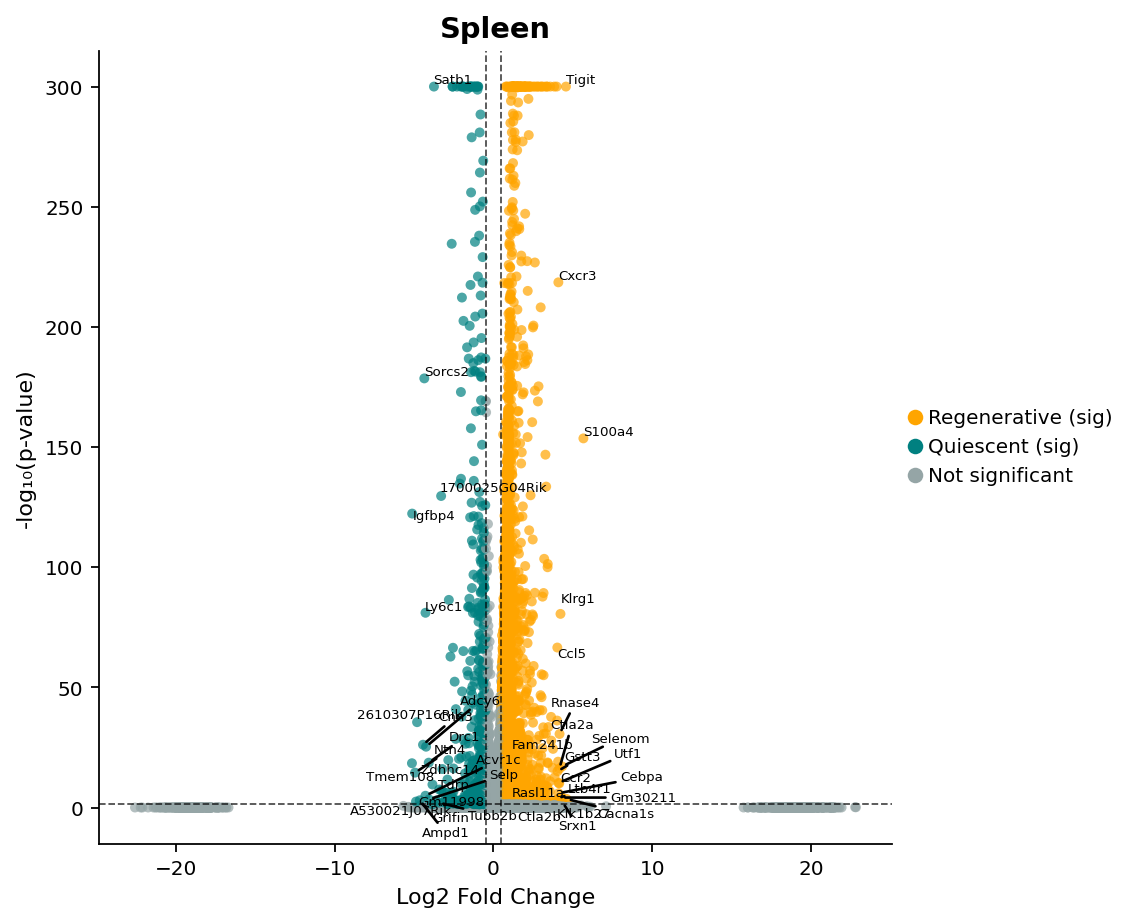

In [82]:
# ── Spleen ─────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

xlsx_path = degs + 'tissues_regen_quiescent.xlsx'
LFC_CUTOFF = 0.5
PVAL_CUTOFF = 0.05
N_LABELS = 20
DOT_SIZE = 20  # increase to make dots bigger
LABEL_GENES = []  # e.g. ['FOXP3', 'IL2RA'] — overrides auto top-N when non-empty

sheet = '1_Spleen'
try:
    df = pd.read_excel(xlsx_path, sheet_name=sheet)
except Exception:
    print(f'Sheet {sheet} not found — tissue may have been skipped during DEG analysis.')
    raise

lfc_col  = [c for c in df.columns if c.endswith('_l')][0]
pval_col = [c for c in df.columns if c.endswith('_p')][0]
name_col = [c for c in df.columns if c.endswith('_n')][0]

df = df.dropna(subset=[lfc_col, pval_col])
df['neglog10p'] = -np.log10(df[pval_col].clip(lower=1e-300))
df['sig'] = (df[lfc_col].abs() >= LFC_CUTOFF) & (df[pval_col] < PVAL_CUTOFF)

def _color(row):
    if row['sig'] and row[lfc_col] >= LFC_CUTOFF:
        return 'Orange'    # upregulated in Regenerative
    elif row['sig'] and row[lfc_col] <= -LFC_CUTOFF:
        return 'Teal'      # upregulated in Quiescent
    return '#95A5A6'       # not significant

colors = df.apply(_color, axis=1)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(df[lfc_col], df['neglog10p'], c=colors, s=DOT_SIZE, alpha=0.7, linewidths=0, rasterized=True)

ax.axvline(x= LFC_CUTOFF, color='black', linestyle='--', linewidth=0.8, alpha=0.7)
ax.axvline(x=-LFC_CUTOFF, color='black', linestyle='--', linewidth=0.8, alpha=0.7)
ax.axhline(y=-np.log10(PVAL_CUTOFF), color='black', linestyle='--', linewidth=0.8, alpha=0.7)

if LABEL_GENES:
    label_df = df[df[name_col].isin(LABEL_GENES)]
else:
    sig_df = df[df['sig']].copy()
    label_df = pd.concat([
        sig_df.nlargest(N_LABELS, lfc_col),
        sig_df.nsmallest(N_LABELS, lfc_col)
    ]).drop_duplicates()
from adjustText import adjust_text
texts = []
for _, row in label_df.iterrows():
    texts.append(ax.text(row[lfc_col], row['neglog10p'], row[name_col],
                         fontsize=6, color='black'))
adjust_text(texts, ax=ax,
            arrowprops=dict(arrowstyle='-', color='black', lw=1.2))

ax.set_title('Spleen', fontsize=13, fontweight='bold')
ax.set_xlabel('Log2 Fold Change', fontsize=10)
ax.set_ylabel('-log₁₀(p-value)', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.set_box_aspect(1)
ax.tick_params(labelsize=9)
ax.grid(False)

from matplotlib.lines import Line2D
regen_handle = Line2D([0], [0], marker='o', color='w', markerfacecolor='Orange',  markersize=8, label='Regenerative (sig)')
quies_handle = Line2D([0], [0], marker='o', color='w', markerfacecolor='Teal',    markersize=8, label='Quiescent (sig)')
insig_handle = Line2D([0], [0], marker='o', color='w', markerfacecolor='#95A5A6', markersize=8, label='Not significant')
ax.legend(handles=[regen_handle, quies_handle, insig_handle], fontsize=9, frameon=False,
          loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.savefig(file_outputs + '0_figures/volcano_spleen.pdf', bbox_inches='tight', dpi=300, transparent=True)
plt.show()

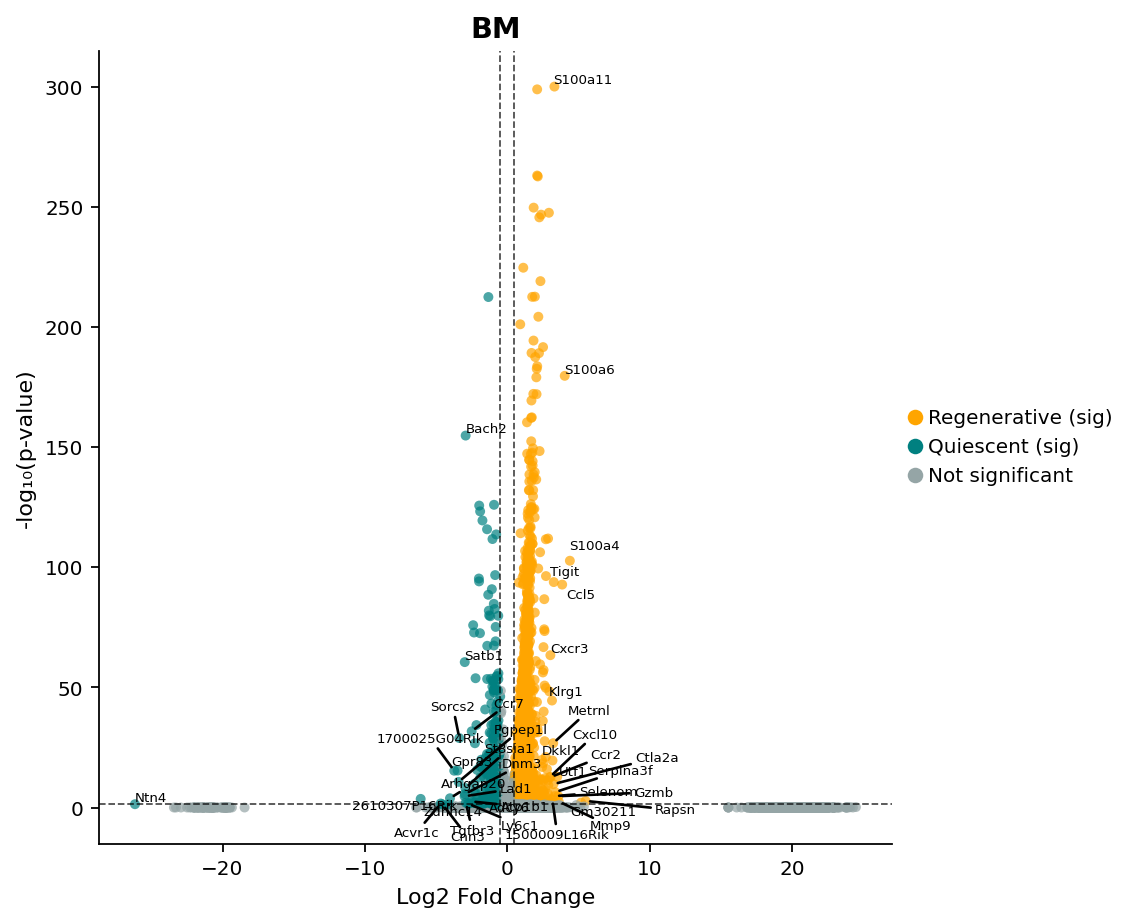

In [83]:
# ── BM ─────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

xlsx_path = degs + 'tissues_regen_quiescent.xlsx'
LFC_CUTOFF = 0.5
PVAL_CUTOFF = 0.05
N_LABELS = 20
DOT_SIZE = 20  # increase to make dots bigger
LABEL_GENES = []  # e.g. ['FOXP3', 'IL2RA'] — overrides auto top-N when non-empty

sheet = '2_BM'
try:
    df = pd.read_excel(xlsx_path, sheet_name=sheet)
except Exception:
    print(f'Sheet {sheet} not found — tissue may have been skipped during DEG analysis.')
    raise

lfc_col  = [c for c in df.columns if c.endswith('_l')][0]
pval_col = [c for c in df.columns if c.endswith('_p')][0]
name_col = [c for c in df.columns if c.endswith('_n')][0]

df = df.dropna(subset=[lfc_col, pval_col])
df['neglog10p'] = -np.log10(df[pval_col].clip(lower=1e-300))
df['sig'] = (df[lfc_col].abs() >= LFC_CUTOFF) & (df[pval_col] < PVAL_CUTOFF)

def _color(row):
    if row['sig'] and row[lfc_col] >= LFC_CUTOFF:
        return 'Orange'    # upregulated in Regenerative
    elif row['sig'] and row[lfc_col] <= -LFC_CUTOFF:
        return 'Teal'      # upregulated in Quiescent
    return '#95A5A6'       # not significant

colors = df.apply(_color, axis=1)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(df[lfc_col], df['neglog10p'], c=colors, s=DOT_SIZE, alpha=0.7, linewidths=0, rasterized=True)

ax.axvline(x= LFC_CUTOFF, color='black', linestyle='--', linewidth=0.8, alpha=0.7)
ax.axvline(x=-LFC_CUTOFF, color='black', linestyle='--', linewidth=0.8, alpha=0.7)
ax.axhline(y=-np.log10(PVAL_CUTOFF), color='black', linestyle='--', linewidth=0.8, alpha=0.7)

if LABEL_GENES:
    label_df = df[df[name_col].isin(LABEL_GENES)]
else:
    sig_df = df[df['sig']].copy()
    label_df = pd.concat([
        sig_df.nlargest(N_LABELS, lfc_col),
        sig_df.nsmallest(N_LABELS, lfc_col)
    ]).drop_duplicates()
from adjustText import adjust_text
texts = []
for _, row in label_df.iterrows():
    texts.append(ax.text(row[lfc_col], row['neglog10p'], row[name_col],
                         fontsize=6, color='black'))
adjust_text(texts, ax=ax,
            arrowprops=dict(arrowstyle='-', color='black', lw=1.2))

ax.set_title('BM', fontsize=13, fontweight='bold')
ax.set_xlabel('Log2 Fold Change', fontsize=10)
ax.set_ylabel('-log₁₀(p-value)', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.set_box_aspect(1)
ax.tick_params(labelsize=9)
ax.grid(False)

from matplotlib.lines import Line2D
regen_handle = Line2D([0], [0], marker='o', color='w', markerfacecolor='Orange',  markersize=8, label='Regenerative (sig)')
quies_handle = Line2D([0], [0], marker='o', color='w', markerfacecolor='Teal',    markersize=8, label='Quiescent (sig)')
insig_handle = Line2D([0], [0], marker='o', color='w', markerfacecolor='#95A5A6', markersize=8, label='Not significant')
ax.legend(handles=[regen_handle, quies_handle, insig_handle], fontsize=9, frameon=False,
          loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.savefig(file_outputs + '0_figures/volcano_bm.pdf', bbox_inches='tight', dpi=300, transparent=True)
plt.show()

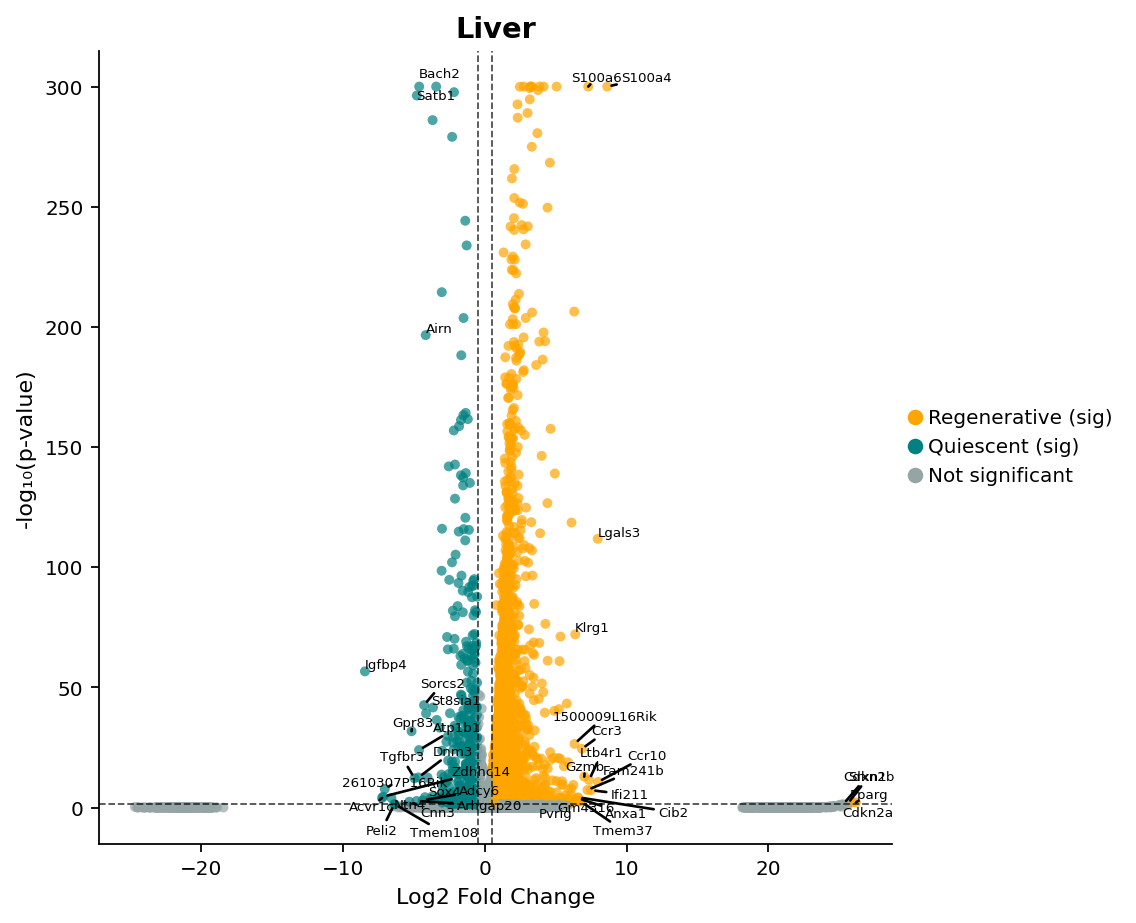

In [84]:
# ── Liver ──────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

xlsx_path = degs + 'tissues_regen_quiescent.xlsx'
LFC_CUTOFF = 0.5
PVAL_CUTOFF = 0.05
N_LABELS = 20
DOT_SIZE = 20  # increase to make dots bigger
LABEL_GENES = []  # e.g. ['FOXP3', 'IL2RA'] — overrides auto top-N when non-empty

sheet = '3_Liver'
try:
    df = pd.read_excel(xlsx_path, sheet_name=sheet)
except Exception:
    print(f'Sheet {sheet} not found — tissue may have been skipped during DEG analysis.')
    raise

lfc_col  = [c for c in df.columns if c.endswith('_l')][0]
pval_col = [c for c in df.columns if c.endswith('_p')][0]
name_col = [c for c in df.columns if c.endswith('_n')][0]

df = df.dropna(subset=[lfc_col, pval_col])
df['neglog10p'] = -np.log10(df[pval_col].clip(lower=1e-300))
df['sig'] = (df[lfc_col].abs() >= LFC_CUTOFF) & (df[pval_col] < PVAL_CUTOFF)

def _color(row):
    if row['sig'] and row[lfc_col] >= LFC_CUTOFF:
        return 'Orange'    # upregulated in Regenerative
    elif row['sig'] and row[lfc_col] <= -LFC_CUTOFF:
        return 'Teal'      # upregulated in Quiescent
    return '#95A5A6'       # not significant

colors = df.apply(_color, axis=1)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(df[lfc_col], df['neglog10p'], c=colors, s=DOT_SIZE, alpha=0.7, linewidths=0, rasterized=True)

ax.axvline(x= LFC_CUTOFF, color='black', linestyle='--', linewidth=0.8, alpha=0.7)
ax.axvline(x=-LFC_CUTOFF, color='black', linestyle='--', linewidth=0.8, alpha=0.7)
ax.axhline(y=-np.log10(PVAL_CUTOFF), color='black', linestyle='--', linewidth=0.8, alpha=0.7)

if LABEL_GENES:
    label_df = df[df[name_col].isin(LABEL_GENES)]
else:
    sig_df = df[df['sig']].copy()
    label_df = pd.concat([
        sig_df.nlargest(N_LABELS, lfc_col),
        sig_df.nsmallest(N_LABELS, lfc_col)
    ]).drop_duplicates()
from adjustText import adjust_text
texts = []
for _, row in label_df.iterrows():
    texts.append(ax.text(row[lfc_col], row['neglog10p'], row[name_col],
                         fontsize=6, color='black'))
adjust_text(texts, ax=ax,
            arrowprops=dict(arrowstyle='-', color='black', lw=1.2))

ax.set_title('Liver', fontsize=13, fontweight='bold')
ax.set_xlabel('Log2 Fold Change', fontsize=10)
ax.set_ylabel('-log₁₀(p-value)', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.set_box_aspect(1)
ax.tick_params(labelsize=9)
ax.grid(False)

from matplotlib.lines import Line2D
regen_handle = Line2D([0], [0], marker='o', color='w', markerfacecolor='Orange',  markersize=8, label='Regenerative (sig)')
quies_handle = Line2D([0], [0], marker='o', color='w', markerfacecolor='Teal',    markersize=8, label='Quiescent (sig)')
insig_handle = Line2D([0], [0], marker='o', color='w', markerfacecolor='#95A5A6', markersize=8, label='Not significant')
ax.legend(handles=[regen_handle, quies_handle, insig_handle], fontsize=9, frameon=False,
          loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.savefig(file_outputs + '0_figures/volcano_liver.pdf', bbox_inches='tight', dpi=300, transparent=True)
plt.show()

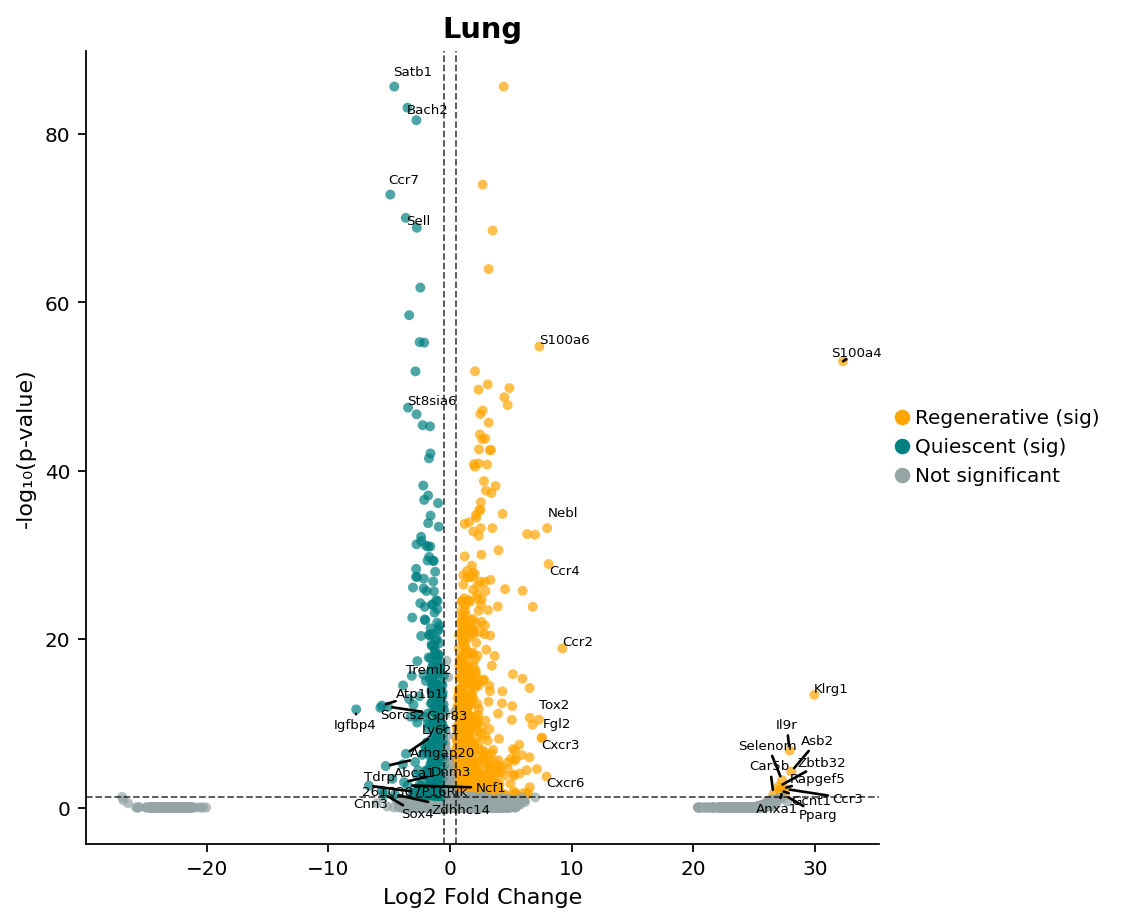

In [85]:
# ── Lung ───────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

xlsx_path = degs + 'tissues_regen_quiescent.xlsx'
LFC_CUTOFF = 0.5
PVAL_CUTOFF = 0.05
N_LABELS = 20
DOT_SIZE = 20  # increase to make dots bigger
LABEL_GENES = []  # e.g. ['FOXP3', 'IL2RA'] — overrides auto top-N when non-empty

sheet = '4_Lung'
try:
    df = pd.read_excel(xlsx_path, sheet_name=sheet)
except Exception:
    print(f'Sheet {sheet} not found — tissue may have been skipped during DEG analysis.')
    raise

lfc_col  = [c for c in df.columns if c.endswith('_l')][0]
pval_col = [c for c in df.columns if c.endswith('_p')][0]
name_col = [c for c in df.columns if c.endswith('_n')][0]

df = df.dropna(subset=[lfc_col, pval_col])
df['neglog10p'] = -np.log10(df[pval_col].clip(lower=1e-300))
df['sig'] = (df[lfc_col].abs() >= LFC_CUTOFF) & (df[pval_col] < PVAL_CUTOFF)

def _color(row):
    if row['sig'] and row[lfc_col] >= LFC_CUTOFF:
        return 'Orange'    # upregulated in Regenerative
    elif row['sig'] and row[lfc_col] <= -LFC_CUTOFF:
        return 'Teal'      # upregulated in Quiescent
    return '#95A5A6'       # not significant

colors = df.apply(_color, axis=1)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(df[lfc_col], df['neglog10p'], c=colors, s=DOT_SIZE, alpha=0.7, linewidths=0, rasterized=True)

ax.axvline(x= LFC_CUTOFF, color='black', linestyle='--', linewidth=0.8, alpha=0.7)
ax.axvline(x=-LFC_CUTOFF, color='black', linestyle='--', linewidth=0.8, alpha=0.7)
ax.axhline(y=-np.log10(PVAL_CUTOFF), color='black', linestyle='--', linewidth=0.8, alpha=0.7)

if LABEL_GENES:
    label_df = df[df[name_col].isin(LABEL_GENES)]
else:
    sig_df = df[df['sig']].copy()
    label_df = pd.concat([
        sig_df.nlargest(N_LABELS, lfc_col),
        sig_df.nsmallest(N_LABELS, lfc_col)
    ]).drop_duplicates()
from adjustText import adjust_text
texts = []
for _, row in label_df.iterrows():
    texts.append(ax.text(row[lfc_col], row['neglog10p'], row[name_col],
                         fontsize=6, color='black'))
adjust_text(texts, ax=ax,
            arrowprops=dict(arrowstyle='-', color='black', lw=1.2))

ax.set_title('Lung', fontsize=13, fontweight='bold')
ax.set_xlabel('Log2 Fold Change', fontsize=10)
ax.set_ylabel('-log₁₀(p-value)', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.set_box_aspect(1)
ax.tick_params(labelsize=9)
ax.grid(False)

from matplotlib.lines import Line2D
regen_handle = Line2D([0], [0], marker='o', color='w', markerfacecolor='Orange',  markersize=8, label='Regenerative (sig)')
quies_handle = Line2D([0], [0], marker='o', color='w', markerfacecolor='Teal',    markersize=8, label='Quiescent (sig)')
insig_handle = Line2D([0], [0], marker='o', color='w', markerfacecolor='#95A5A6', markersize=8, label='Not significant')
ax.legend(handles=[regen_handle, quies_handle, insig_handle], fontsize=9, frameon=False,
          loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.savefig(file_outputs + '0_figures/volcano_lung.pdf', bbox_inches='tight', dpi=300, transparent=True)
plt.show()

In [86]:
# ── Skin ───────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

xlsx_path = degs + 'tissues_regen_quiescent.xlsx'
LFC_CUTOFF = 0.5
PVAL_CUTOFF = 0.05
N_LABELS = 20
DOT_SIZE = 20  # increase to make dots bigger
LABEL_GENES = []  # e.g. ['FOXP3', 'IL2RA'] — overrides auto top-N when non-empty

sheet = '5_Skin'
try:
    df = pd.read_excel(xlsx_path, sheet_name=sheet)
except Exception:
    print(f'Sheet {sheet} not found — tissue may have been skipped during DEG analysis.')
    raise

lfc_col  = [c for c in df.columns if c.endswith('_l')][0]
pval_col = [c for c in df.columns if c.endswith('_p')][0]
name_col = [c for c in df.columns if c.endswith('_n')][0]

df = df.dropna(subset=[lfc_col, pval_col])
df['neglog10p'] = -np.log10(df[pval_col].clip(lower=1e-300))
df['sig'] = (df[lfc_col].abs() >= LFC_CUTOFF) & (df[pval_col] < PVAL_CUTOFF)

def _color(row):
    if row['sig'] and row[lfc_col] >= LFC_CUTOFF:
        return 'Orange'    # upregulated in Regenerative
    elif row['sig'] and row[lfc_col] <= -LFC_CUTOFF:
        return 'Teal'      # upregulated in Quiescent
    return '#95A5A6'       # not significant

colors = df.apply(_color, axis=1)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(df[lfc_col], df['neglog10p'], c=colors, s=DOT_SIZE, alpha=0.7, linewidths=0, rasterized=True)

ax.axvline(x= LFC_CUTOFF, color='black', linestyle='--', linewidth=0.8, alpha=0.7)
ax.axvline(x=-LFC_CUTOFF, color='black', linestyle='--', linewidth=0.8, alpha=0.7)
ax.axhline(y=-np.log10(PVAL_CUTOFF), color='black', linestyle='--', linewidth=0.8, alpha=0.7)

if LABEL_GENES:
    label_df = df[df[name_col].isin(LABEL_GENES)]
else:
    sig_df = df[df['sig']].copy()
    label_df = pd.concat([
        sig_df.nlargest(N_LABELS, lfc_col),
        sig_df.nsmallest(N_LABELS, lfc_col)
    ]).drop_duplicates()
from adjustText import adjust_text
texts = []
for _, row in label_df.iterrows():
    texts.append(ax.text(row[lfc_col], row['neglog10p'], row[name_col],
                         fontsize=6, color='black'))
adjust_text(texts, ax=ax,
            arrowprops=dict(arrowstyle='-', color='black', lw=1.2))

ax.set_title('Skin', fontsize=13, fontweight='bold')
ax.set_xlabel('Log2 Fold Change', fontsize=10)
ax.set_ylabel('-log₁₀(p-value)', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.set_box_aspect(1)
ax.tick_params(labelsize=9)
ax.grid(False)

from matplotlib.lines import Line2D
regen_handle = Line2D([0], [0], marker='o', color='w', markerfacecolor='Orange',  markersize=8, label='Regenerative (sig)')
quies_handle = Line2D([0], [0], marker='o', color='w', markerfacecolor='Teal',    markersize=8, label='Quiescent (sig)')
insig_handle = Line2D([0], [0], marker='o', color='w', markerfacecolor='#95A5A6', markersize=8, label='Not significant')
ax.legend(handles=[regen_handle, quies_handle, insig_handle], fontsize=9, frameon=False,
          loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.savefig(file_outputs + '0_figures/volcano_skin.pdf', bbox_inches='tight', dpi=300, transparent=True)
plt.show()

Sheet 5_Skin not found — tissue may have been skipped during DEG analysis.


ValueError: Worksheet named '5_Skin' not found